In [47]:
import pandas as pd

df_casas = pd.read_csv("../Output/casas.csv", low_memory=False)
df_poblacion = pd.read_csv("../Output/poblacion.csv")
df_rentas = pd.read_csv("../Output/rentas_espana_limpia.csv")

In [48]:
df_casas.head()

,ad_last_update,bath_num,condition,construct_date,energetic_certif,house_id,house_type,loc_city,loc_district,loc_full,loc_zone,m2_real,m2_useful,obtention_date,orientation,price,room_num,provincia
0,Anuncio actualizado el 27 de marzo,2.0,segunda mano/buen estado,NaN,no indicado,81717634,Casa o chalet independiente,Urcabustaiz,La iglesia,"La iglesia , Urcabustaiz , Zuya, Álava","Zuya, Álava",1000.0,172.0,2019-03-29,"norte, sur, este, oeste",310000.0,4.0,alava
1,más de 5 meses sin actualizar,2.0,segunda mano/buen estado,1970-01-01 00:00:00.000002006,no indicado,29588074,Ático,Legutiano,"la Union Plazatxoa, 8","la Union Plazatxoa, 8 , Legutiano , Zuya, Álava","Zuya, Álava",86.0,NaN,2019-03-29,NaN,139000.0,3.0,alava
2,más de 5 meses sin actualizar,3.0,segunda mano/buen estado,NaN,no indicado,37453116,Casa de pueblo,Aramaio,Calle Etxaguen s/n,"Calle Etxaguen s/n , Aramaio , Zuya, Álava","Zuya, Álava",3000.0,NaN,2019-03-29,NaN,480000.0,4.0,alava
3,más de 5 meses sin actualizar,1.0,segunda mano/buen estado,NaN,en trámite,82568918,Casa de pueblo,Urcabustaiz,"CP 01449, 1449 CP","CP 01449, 1449 CP , Urcabustaiz , Zuya, Álava","Zuya, Álava",86.0,NaN,2019-03-29,NaN,150000.0,4.0,alava
4,más de 5 meses sin actualizar,1.0,segunda mano/buen estado,NaN,no indicado,29135242,Piso,Urcabustaiz,"Calle Nueva Plaza, 9","Calle Nueva Plaza, 9 , Urcabustaiz , Zuya, Ál...","Zuya, Álava",76.0,74.0,2019-03-29,"sur, oeste",90000.0,2.0,alava


In [49]:
df_poblacion.head()

,provincia,source,poblacion_total,cod_provincia
0,albacete,Empresas,26743,2
1,alicante,Empresas,138964,3
2,almeria,Empresas,42931,4
3,alava,Empresas,19147,1
4,asturias,Empresas,68688,33


In [50]:
df_rentas.head()

,Número de declaraciones,Renta bruta media,Renta disponible media,Rentas del trabajo,Rentas exentas,Renta bruta,Cotizaciones sociales a la SS,Cuota resultante de autoliquidación,Renta disponible,provincia,Id Municipio
0,75867,23.037,19.415,1456012595,71236502,1747748989,71001490,203864325,1472973679,Jerez de la Frontera,11020
1,139685,24.956,20.590,2872080318,95447256,3486036496,131696823,478299401,2876132145,Córdoba,14021
2,107278,27.895,22.856,2348548998,127809334,2992558477,98352388,442317860,2451956604,Granada,18087
3,219677,25.180,20.980,4392190510,257940065,5531461016,208101984,714702889,4608791911,Málaga,29067
4,288039,28.019,22.822,6557221055,290595019,8070490996,292398468,1204652257,6573711090,Sevilla,41091


In [51]:
# Merge con población
df_final = df_casas.merge(
    df_poblacion,
    on='provincia',
    how='left'
)

print(f"Filas: {df_final.shape[0]}")
print(f"Columnas: {df_final.shape[1]}")


Filas: 199632
Columnas: 21


In [52]:
sin_match = set(df_casas['provincia'].str.lower()) - set(df_poblacion['provincia'].str.lower())
print(sin_match)

set()


In [53]:
df_final.head()

,ad_last_update,bath_num,condition,construct_date,energetic_certif,house_id,house_type,loc_city,loc_district,loc_full,...,m2_real,m2_useful,obtention_date,orientation,price,room_num,provincia,source,poblacion_total,cod_provincia
0,Anuncio actualizado el 27 de marzo,2.0,segunda mano/buen estado,NaN,no indicado,81717634,Casa o chalet independiente,Urcabustaiz,La iglesia,"La iglesia , Urcabustaiz , Zuya, Álava",...,1000.0,172.0,2019-03-29,"norte, sur, este, oeste",310000.0,4.0,alava,Empresas,19147,1
1,Anuncio actualizado el 27 de marzo,2.0,segunda mano/buen estado,NaN,no indicado,81717634,Casa o chalet independiente,Urcabustaiz,La iglesia,"La iglesia , Urcabustaiz , Zuya, Álava",...,1000.0,172.0,2019-03-29,"norte, sur, este, oeste",310000.0,4.0,alava,Poblacion,328868,1
2,más de 5 meses sin actualizar,2.0,segunda mano/buen estado,1970-01-01 00:00:00.000002006,no indicado,29588074,Ático,Legutiano,"la Union Plazatxoa, 8","la Union Plazatxoa, 8 , Legutiano , Zuya, Álava",...,86.0,NaN,2019-03-29,NaN,139000.0,3.0,alava,Empresas,19147,1
3,más de 5 meses sin actualizar,2.0,segunda mano/buen estado,1970-01-01 00:00:00.000002006,no indicado,29588074,Ático,Legutiano,"la Union Plazatxoa, 8","la Union Plazatxoa, 8 , Legutiano , Zuya, Álava",...,86.0,NaN,2019-03-29,NaN,139000.0,3.0,alava,Poblacion,328868,1
4,más de 5 meses sin actualizar,3.0,segunda mano/buen estado,NaN,no indicado,37453116,Casa de pueblo,Aramaio,Calle Etxaguen s/n,"Calle Etxaguen s/n , Aramaio , Zuya, Álava",...,3000.0,NaN,2019-03-29,NaN,480000.0,4.0,alava,Empresas,19147,1


In [54]:
df = df_final
df.head()

,ad_last_update,bath_num,condition,construct_date,energetic_certif,house_id,house_type,loc_city,loc_district,loc_full,...,m2_real,m2_useful,obtention_date,orientation,price,room_num,provincia,source,poblacion_total,cod_provincia
0,Anuncio actualizado el 27 de marzo,2.0,segunda mano/buen estado,NaN,no indicado,81717634,Casa o chalet independiente,Urcabustaiz,La iglesia,"La iglesia , Urcabustaiz , Zuya, Álava",...,1000.0,172.0,2019-03-29,"norte, sur, este, oeste",310000.0,4.0,alava,Empresas,19147,1
1,Anuncio actualizado el 27 de marzo,2.0,segunda mano/buen estado,NaN,no indicado,81717634,Casa o chalet independiente,Urcabustaiz,La iglesia,"La iglesia , Urcabustaiz , Zuya, Álava",...,1000.0,172.0,2019-03-29,"norte, sur, este, oeste",310000.0,4.0,alava,Poblacion,328868,1
2,más de 5 meses sin actualizar,2.0,segunda mano/buen estado,1970-01-01 00:00:00.000002006,no indicado,29588074,Ático,Legutiano,"la Union Plazatxoa, 8","la Union Plazatxoa, 8 , Legutiano , Zuya, Álava",...,86.0,NaN,2019-03-29,NaN,139000.0,3.0,alava,Empresas,19147,1
3,más de 5 meses sin actualizar,2.0,segunda mano/buen estado,1970-01-01 00:00:00.000002006,no indicado,29588074,Ático,Legutiano,"la Union Plazatxoa, 8","la Union Plazatxoa, 8 , Legutiano , Zuya, Álava",...,86.0,NaN,2019-03-29,NaN,139000.0,3.0,alava,Poblacion,328868,1
4,más de 5 meses sin actualizar,3.0,segunda mano/buen estado,NaN,no indicado,37453116,Casa de pueblo,Aramaio,Calle Etxaguen s/n,"Calle Etxaguen s/n , Aramaio , Zuya, Álava",...,3000.0,NaN,2019-03-29,NaN,480000.0,4.0,alava,Empresas,19147,1


In [55]:
# Vemos que no hay filas duplicadas
df.duplicated().sum()

0

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199632 entries, 0 to 199631
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ad_last_update    199632 non-null  object 
 1   bath_num          198276 non-null  float64
 2   condition         199632 non-null  object 
 3   construct_date    63744 non-null   object 
 4   energetic_certif  199632 non-null  object 
 5   house_id          199632 non-null  int64  
 6   house_type        199632 non-null  object 
 7   loc_city          199632 non-null  object 
 8   loc_district      199632 non-null  object 
 9   loc_full          199632 non-null  object 
 10  loc_zone          199632 non-null  object 
 11  m2_real           199632 non-null  float64
 12  m2_useful         105320 non-null  float64
 13  obtention_date    199632 non-null  object 
 14  orientation       78464 non-null   object 
 15  price             199632 non-null  float64
 16  room_num          19

In [57]:
# Cambiamos los tipos de datos de las diferentes columnas
df['construct_date'] = pd.to_datetime(df['construct_date'], errors='coerce')
df['obtention_date'] = pd.to_datetime(df['obtention_date'], errors='coerce')

df['bath_num'] = df['bath_num'].astype('Int64')
df['room_num'] = df['room_num'].astype('Int64')

df['condition'] = df['condition'].astype('category')
df['house_type'] = df['house_type'].astype('category')
df['energetic_certif'] = df['energetic_certif'].astype('category')
df['orientation'] = df['orientation'].astype('category')

In [58]:
print(df_final.dtypes)

ad_last_update              object
bath_num                     Int64
condition                 category
construct_date      datetime64[ns]
energetic_certif          category
house_id                     int64
house_type                category
loc_city                    object
loc_district                object
loc_full                    object
loc_zone                    object
m2_real                    float64
m2_useful                  float64
obtention_date      datetime64[ns]
orientation               category
price                      float64
room_num                     Int64
provincia                   object
source                      object
poblacion_total              int64
cod_provincia                int64
dtype: object


In [59]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['category']).columns

print(f"Columnas numéricas: {num_cols.tolist()}")
print(f"Columnas categóricas: {cat_cols.tolist()}") 

print("Veamos las estadísticas descriptivas básicas:\n")
df.describe().T.round(2)

Columnas numéricas: ['bath_num', 'house_id', 'm2_real', 'm2_useful', 'price', 'room_num', 'poblacion_total', 'cod_provincia']
Columnas categóricas: ['condition', 'energetic_certif', 'house_type', 'orientation']
Veamos las estadísticas descriptivas básicas:



,count,mean,min,25%,50%,75%,max,std
bath_num,198276.0,1.984406,1.0,1.0,2.0,2.0,20.0,1.137843
construct_date,15638,1973-03-13 22:42:50.047322336,1700-01-01 00:00:00,1970-01-01 00:00:00.000001966,1970-01-01 00:00:00.000001985,1970-01-01 00:00:00.000002007,2021-01-01 00:00:00,NaN
house_id,199632.0,64261402.534644,153995.0,38345365.0,82379308.0,84161765.75,85073788.0,25342423.787759
m2_real,199632.0,1701.933157,1.0,80.0,112.0,240.0,900000.0,18225.940914
m2_useful,105320.0,140.516863,1.0,70.0,92.0,150.0,140000.0,746.720478
obtention_date,199632,2019-04-06 21:47:42.515027968,2019-03-26 00:00:00,2019-03-31 00:00:00,2019-04-09 00:00:00,2019-04-12 00:00:00,2019-04-15 00:00:00,NaN
price,199632.0,379392.874249,1.0,120000.0,212000.0,395000.0,23000000.0,615499.546685
room_num,197080.0,3.23835,1.0,2.0,3.0,4.0,20.0,1.409059
poblacion_total,199632.0,726972.323034,5689.0,75628.0,177717.0,1128908.0,6578079.0,1160080.192092
cod_provincia,199632.0,24.360313,1.0,7.0,20.0,48.0,49.0,18.077525



----- condition -----
Valores únicos: 4
Frecuencia:
condition
segunda mano/buen estado      144542
Desconocido                    27882
segunda mano/para reformar     22090
promoción de obra nueva         5118
Name: count, dtype: int64


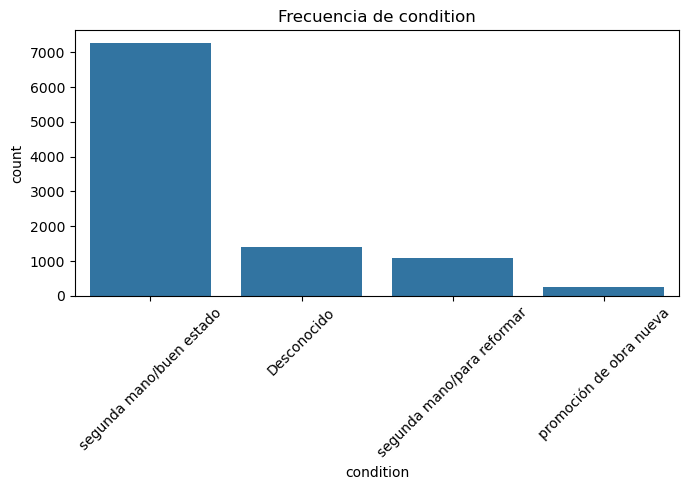


----- energetic_certif -----
Valores únicos: 3
Frecuencia:
energetic_certif
no indicado        102134
en trámite          93914
inmueble exento      3584
Name: count, dtype: int64


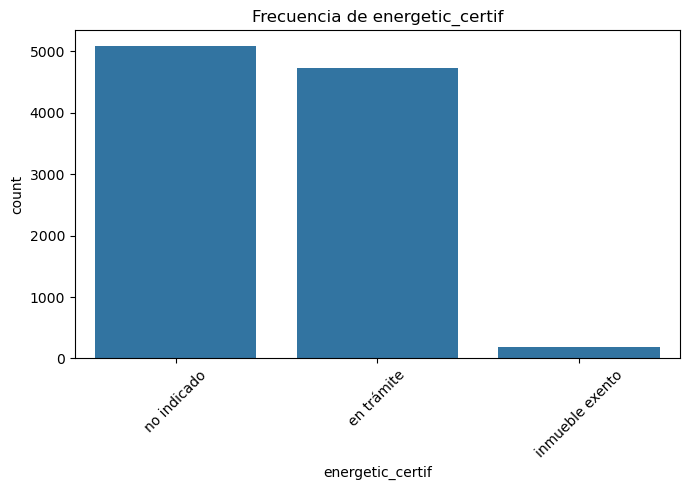


----- house_type -----
Valores únicos: 31
Frecuencia:
house_type
Piso                            107926
 Casa o chalet independiente     27184
 Casa o chalet                   13736
 Chalet adosado                  12882
Ático                             6690
 Casa de pueblo                   6002
Dúplex                            5154
 Chalet pareado                   4964
 Finca rústica                    4552
Alquiler de Piso                  4488
Name: count, dtype: int64
Demasiadas categorías (31), saltando gráfico.

----- orientation -----
Valores únicos: 15
Frecuencia:
orientation
sur                        26668
este                       10874
sur, este                   8202
oeste                       6696
sur, oeste                  5918
este, oeste                 4286
norte                       4042
norte, sur                  2988
norte, sur, este, oeste     2506
norte, este                 1690
Name: count, dtype: int64


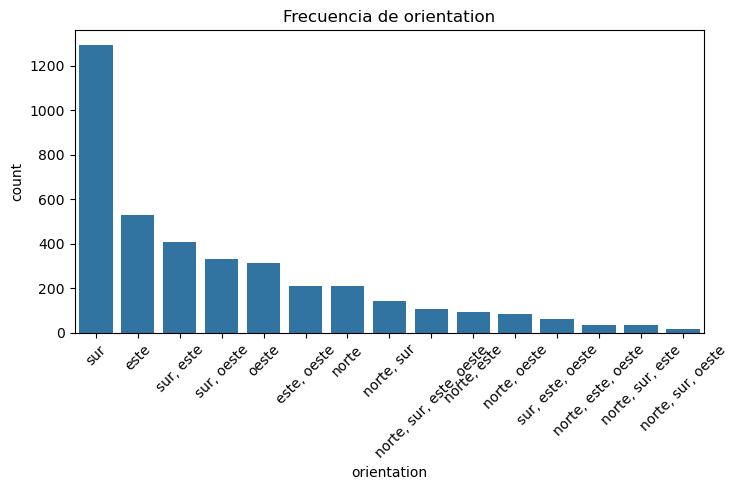

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Trabajamos con una muestra para visualización
df_sample = df.sample(n=10000, random_state=42)

# CATEGÓRICAS
for col in cat_cols:
    print(f"\n----- {col} -----")
    print(f"Valores únicos: {df[col].nunique()}")
    print(f"Frecuencia:\n{df[col].value_counts().head(10)}")  # Solo top 10

    if df[col].nunique() > 20:
        print(f"Demasiadas categorías ({df[col].nunique()}), saltando gráfico.")
        continue  # Salta al siguiente

    num_categories = df[col].nunique()
    plt.figure(figsize=(max(7, num_categories * 0.5), 5))
    sns.countplot(data=df_sample, x=col, order=df_sample[col].value_counts().index)
    plt.title(f"Frecuencia de {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



----- bath_num -----
count    198276.0
mean     1.984406
std      1.137843
min           1.0
25%           1.0
50%           2.0
75%           2.0
max          20.0
Name: bath_num, dtype: Float64


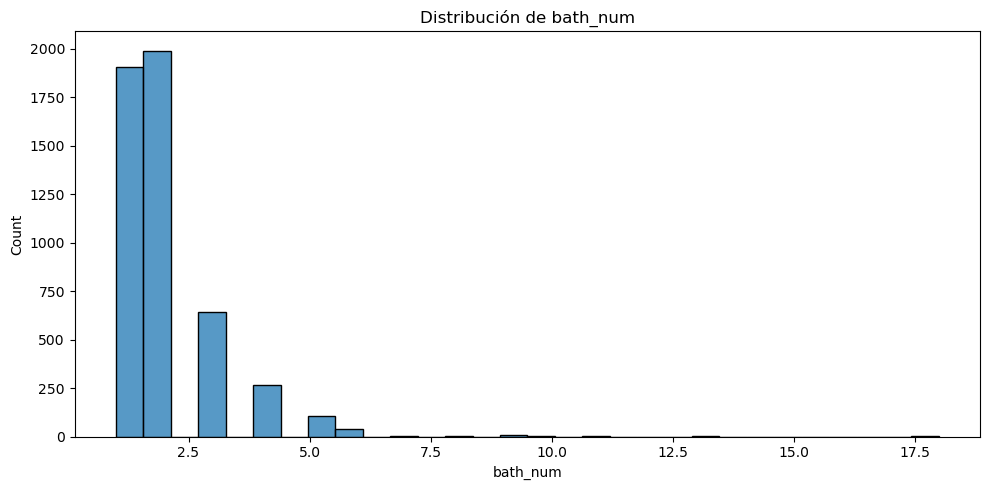


----- house_id -----
count    1.996320e+05
mean     6.426140e+07
std      2.534242e+07
min      1.539950e+05
25%      3.834536e+07
50%      8.237931e+07
75%      8.416177e+07
max      8.507379e+07
Name: house_id, dtype: float64


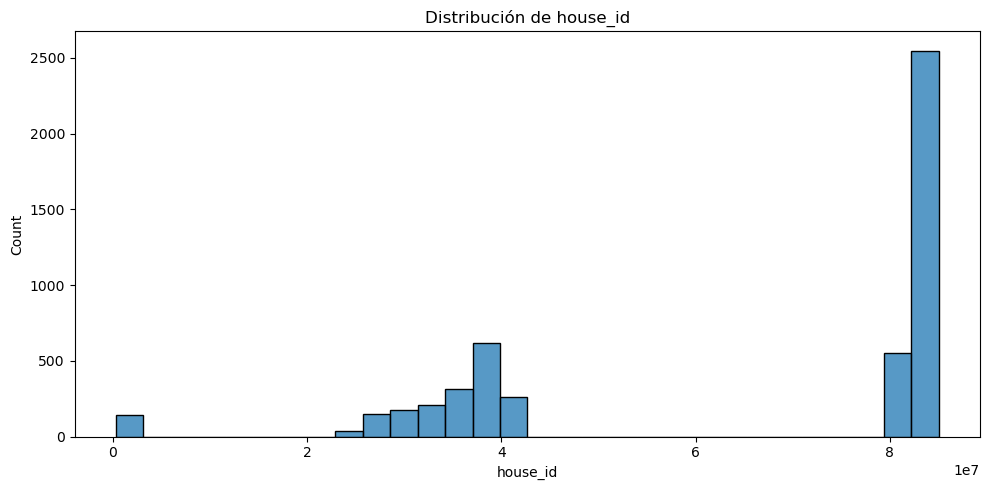


----- m2_real -----
count    199632.000000
mean       1701.933157
std       18225.940914
min           1.000000
25%          80.000000
50%         112.000000
75%         240.000000
max      900000.000000
Name: m2_real, dtype: float64


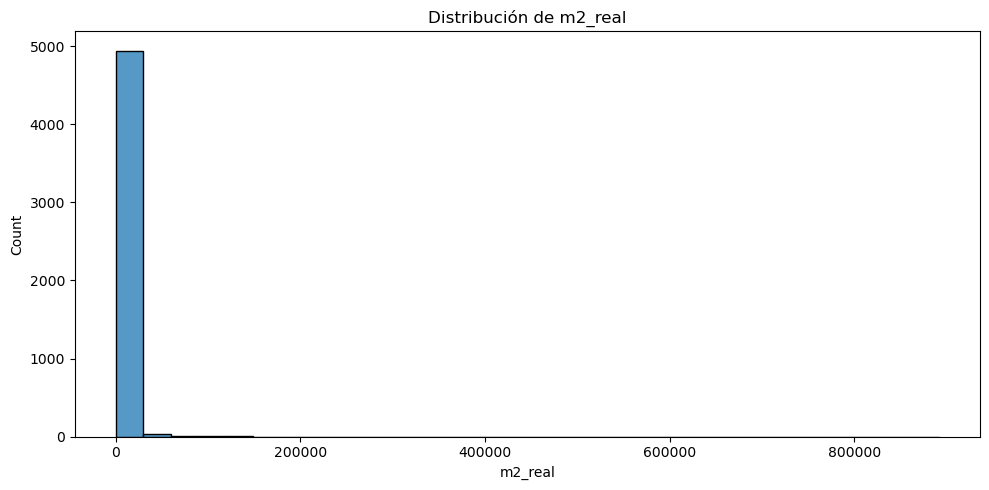


----- m2_useful -----
count    105320.000000
mean        140.516863
std         746.720478
min           1.000000
25%          70.000000
50%          92.000000
75%         150.000000
max      140000.000000
Name: m2_useful, dtype: float64


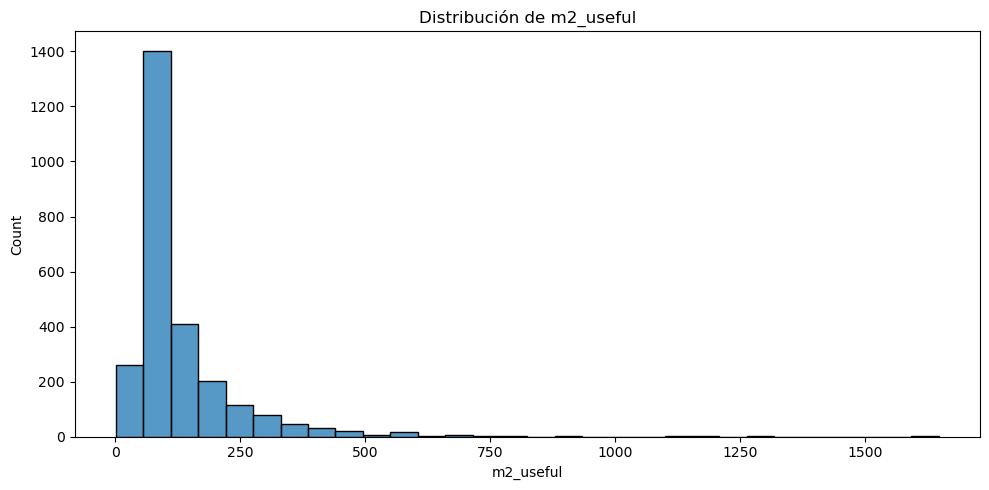


----- price -----
count    1.996320e+05
mean     3.793929e+05
std      6.154995e+05
min      1.000000e+00
25%      1.200000e+05
50%      2.120000e+05
75%      3.950000e+05
max      2.300000e+07
Name: price, dtype: float64


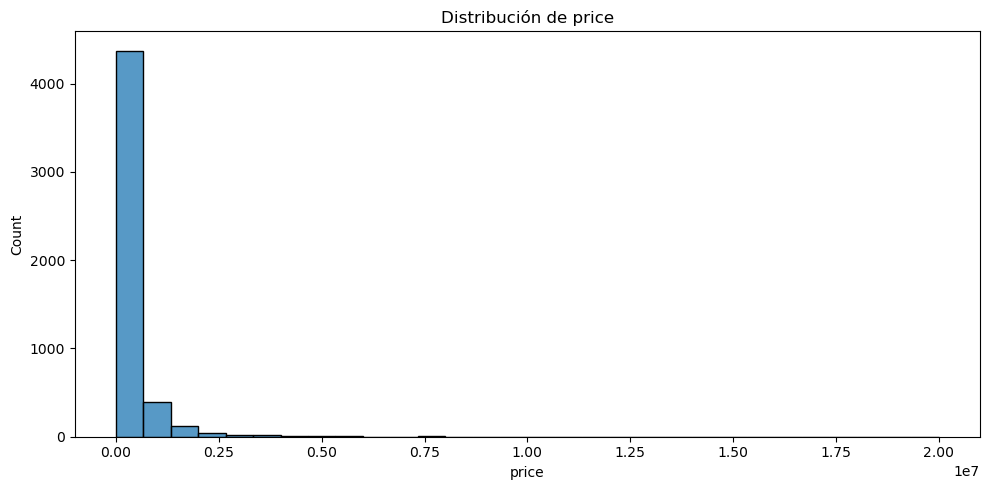


----- room_num -----
count    197080.0
mean      3.23835
std      1.409059
min           1.0
25%           2.0
50%           3.0
75%           4.0
max          20.0
Name: room_num, dtype: Float64


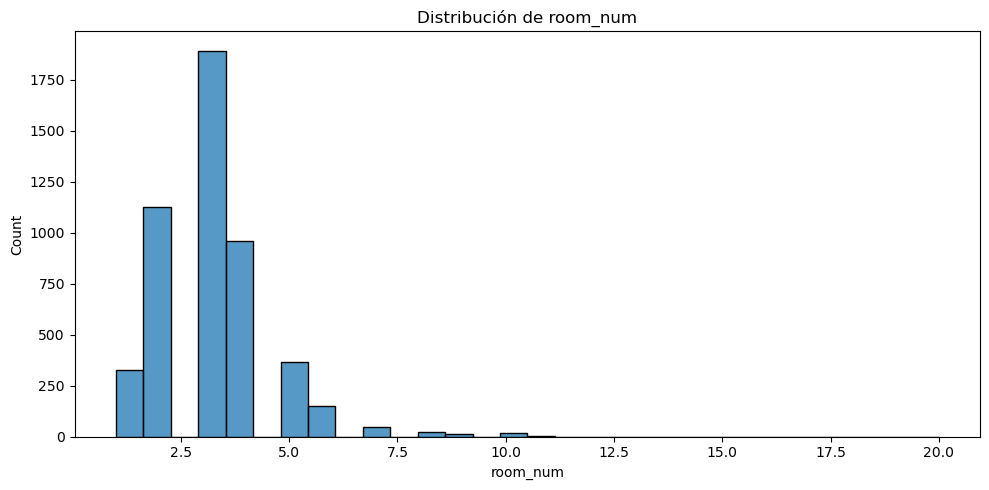


----- poblacion_total -----
count    1.996320e+05
mean     7.269723e+05
std      1.160080e+06
min      5.689000e+03
25%      7.562800e+04
50%      1.777170e+05
75%      1.128908e+06
max      6.578079e+06
Name: poblacion_total, dtype: float64


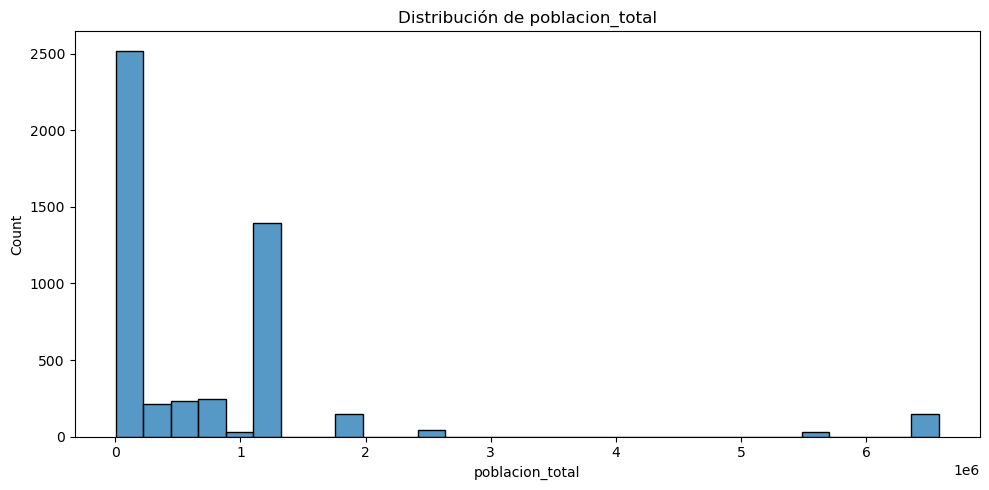


----- cod_provincia -----
count    199632.000000
mean         24.360313
std          18.077525
min           1.000000
25%           7.000000
50%          20.000000
75%          48.000000
max          49.000000
Name: cod_provincia, dtype: float64


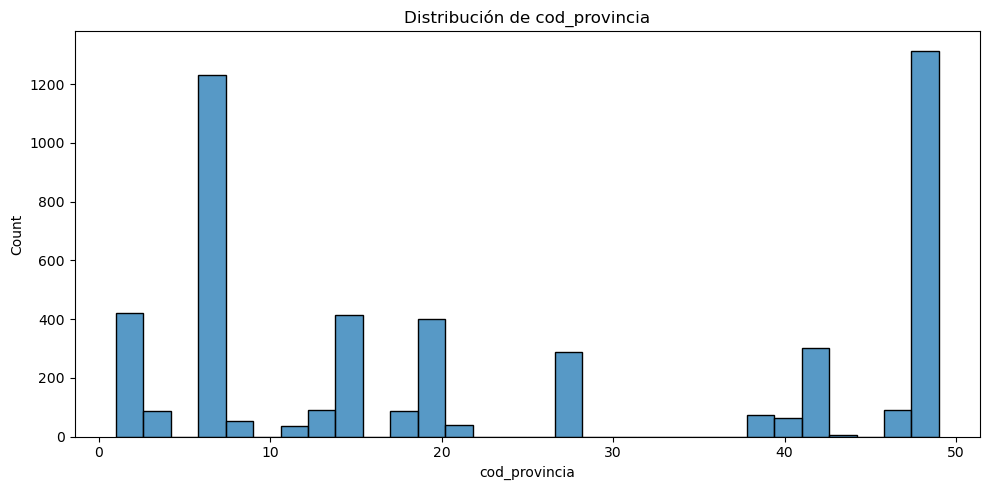

In [61]:
# NUMÉRICAS
df_sample = df.sample(n=5000, random_state=42)

for col in num_cols:
    print(f"\n----- {col} -----")
    print(df[col].describe())
    
    plt.figure(figsize=(10, 5))
    sns.histplot(df_sample[col].dropna(), kde=False, bins=30)  # kde=False es mucho más rápido
    plt.title(f"Distribución de {col}")
    plt.tight_layout()
    plt.show()

In [62]:
matriz_corr = df[num_cols].corr()
matriz_corr

,bath_num,house_id,m2_real,m2_useful,price,room_num,poblacion_total,cod_provincia
bath_num,1.000000,-0.025193,0.109790,0.112724,0.553018,0.646031,-0.014222,-0.096036
house_id,-0.025193,1.000000,-0.004947,-0.010317,0.042166,-0.067294,0.084368,-0.035918
m2_real,0.109790,-0.004947,1.000000,0.053585,0.207207,0.123519,-0.005432,-0.053776
m2_useful,0.112724,-0.010317,0.053585,1.000000,0.103909,0.114565,-0.001849,-0.018348
price,0.553018,0.042166,0.207207,0.103909,1.000000,0.370239,0.032391,-0.160256
room_num,0.646031,-0.067294,0.123519,0.114565,0.370239,1.000000,-0.032739,-0.054269
poblacion_total,-0.014222,0.084368,-0.005432,-0.001849,0.032391,-0.032739,1.000000,0.042740
cod_provincia,-0.096036,-0.035918,-0.053776,-0.018348,-0.160256,-0.054269,0.042740,1.000000


In [63]:
# Relaciones cruzadas
col_num = 'price'

cols_num = df.select_dtypes(include=['int64', 'float64']).columns.drop(col_num)

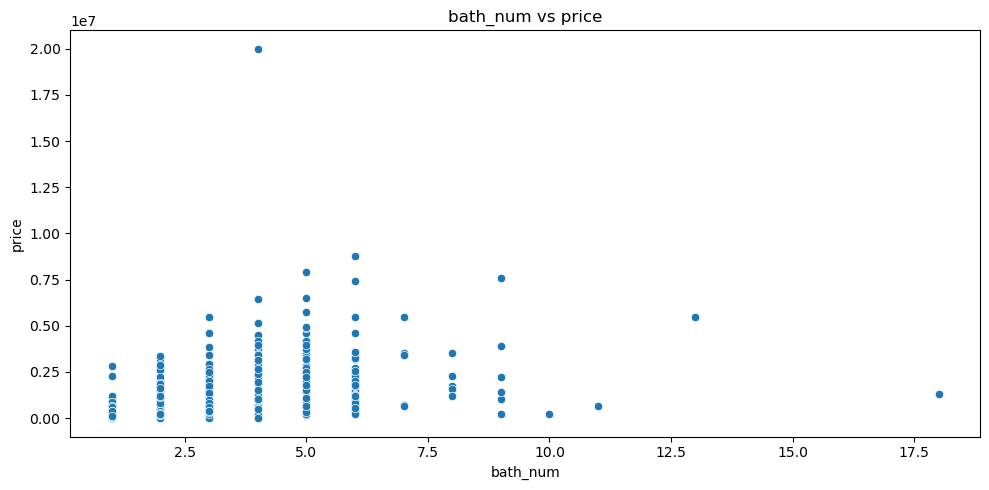

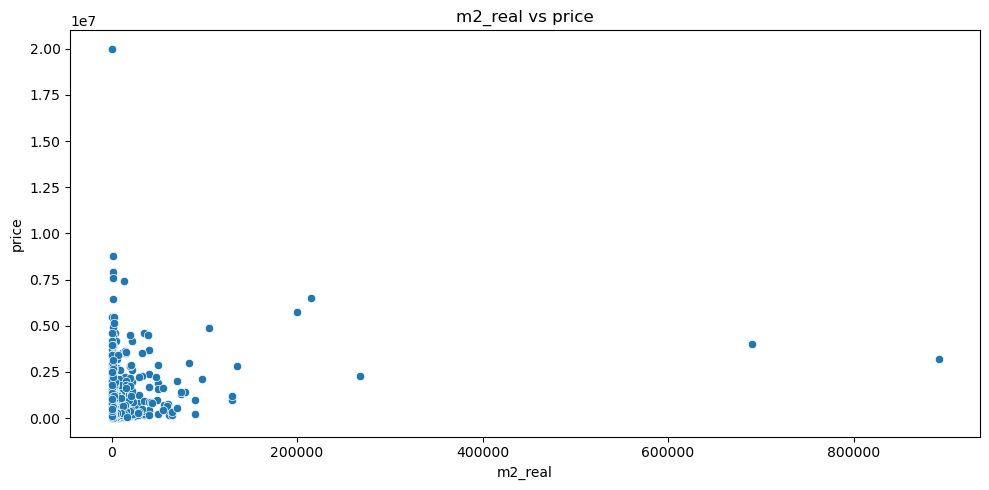

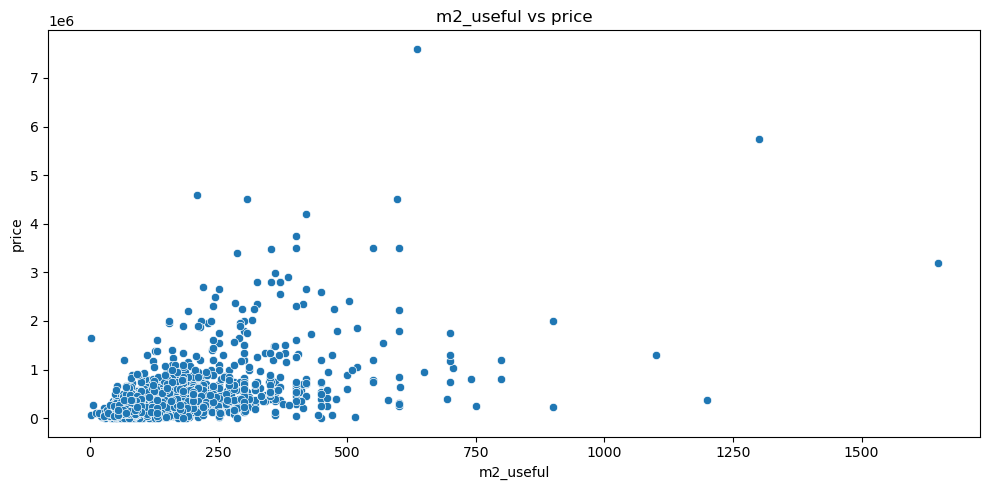

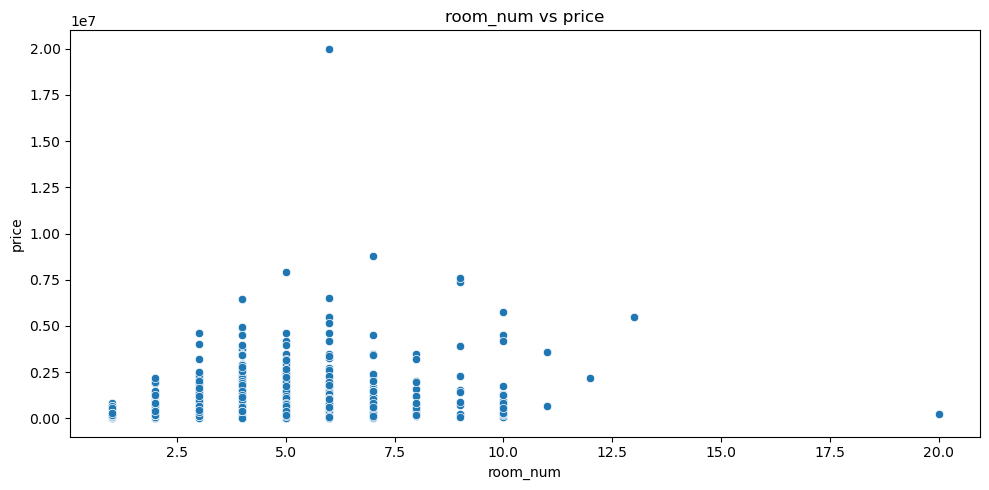

In [64]:
for col in cols_num:
    if col in ['house_id', 'cod_provincia', 'poblacion_total']:
        continue
    
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=df_sample, x=col, y='price')
    plt.title(f"{col} vs price")
    plt.tight_layout()
    plt.show()

## Lo principal que podemos ver es la diferencia entre la relcion de precio con m cuadrados reales y útiles

### Vemos como no hay mucha relacion entre el precio y los M cuadrados reales, sin embargo, con los útiles sí, ya que cuanto mas elevados sean los M útiles, mayor es el precio


C:\Users\pablo\AppData\Local\Temp\ipykernel_4168\2288845130.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cats_ordenadas = df.groupby(col)[col_num].mean().sort_values().index


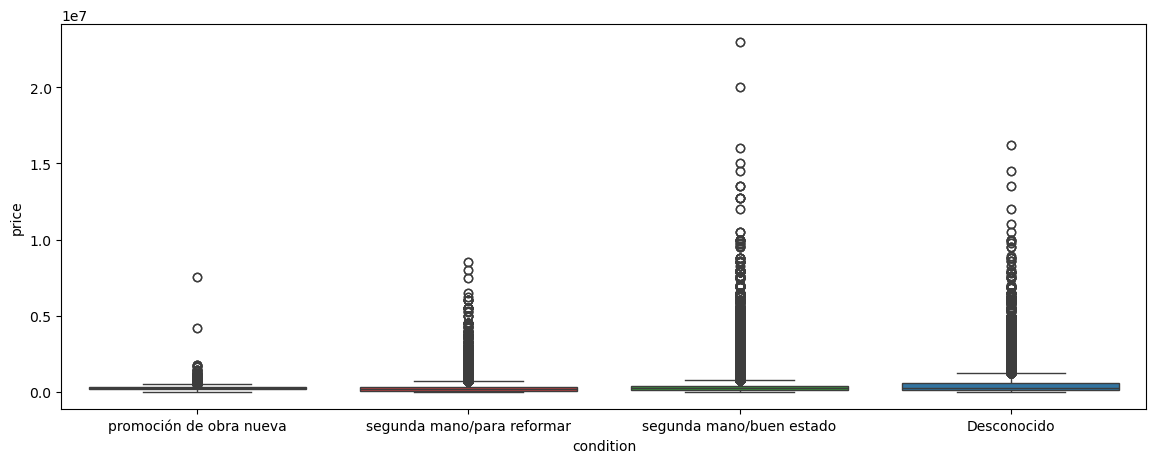

C:\Users\pablo\AppData\Local\Temp\ipykernel_4168\2288845130.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cats_ordenadas = df.groupby(col)[col_num].mean().sort_values().index


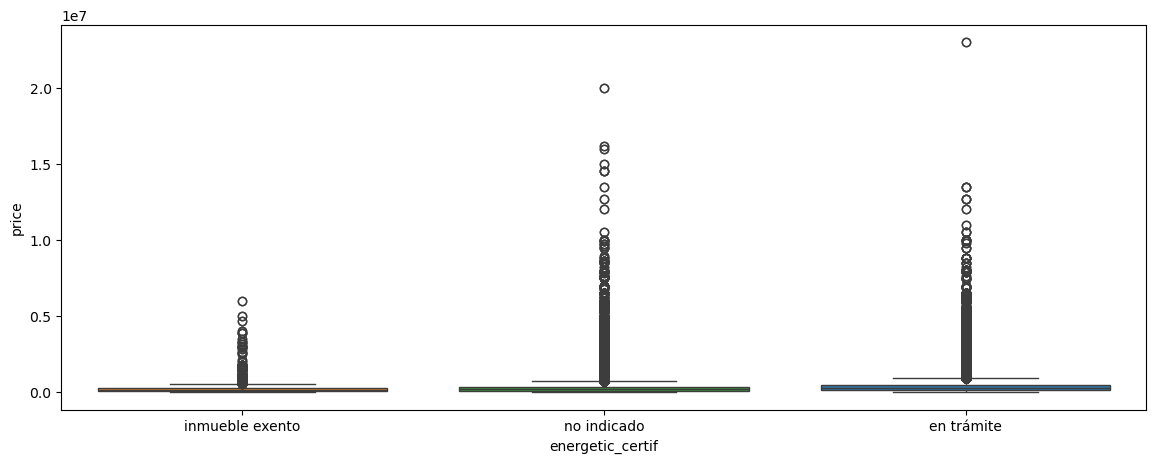

C:\Users\pablo\AppData\Local\Temp\ipykernel_4168\2288845130.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cats_ordenadas = df.groupby(col)[col_num].mean().sort_values().index


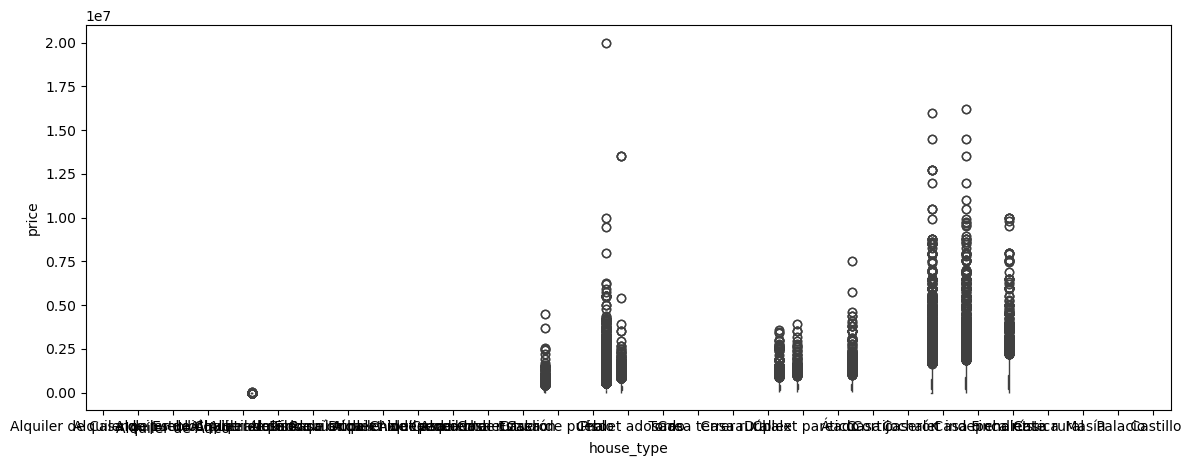

C:\Users\pablo\AppData\Local\Temp\ipykernel_4168\2288845130.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cats_ordenadas = df.groupby(col)[col_num].mean().sort_values().index


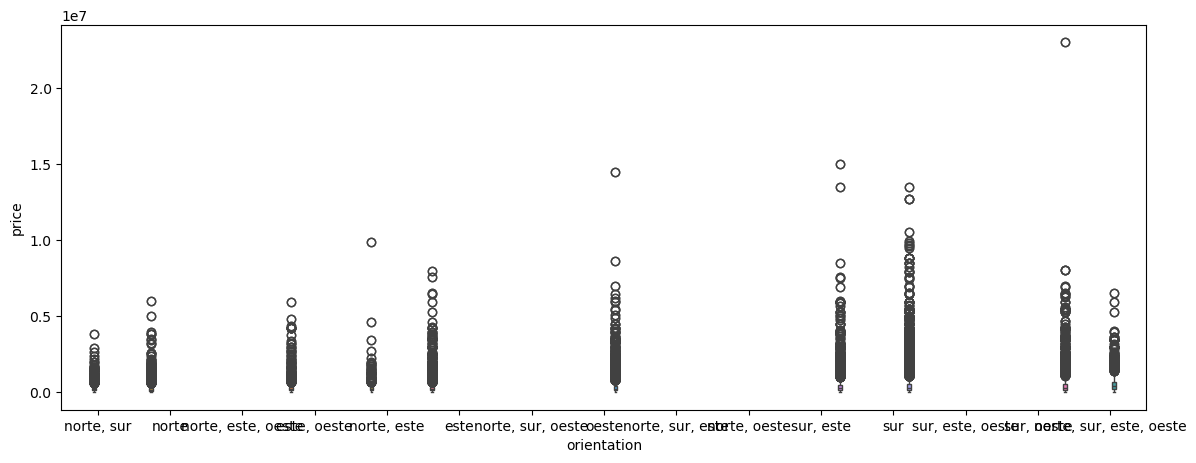

In [ ]:
cols_cat = df.select_dtypes(include=['category']).columns

for col in cols_cat:

    top10 = df[col].value_counts().head(10).index # Solo las 10 categorías más frecuentes
    df_filtrado = df[df[col].isin(top10)]

    cats_ordenadas = df.groupby(col)[col_num].mean().sort_values().index

    plt.figure(figsize=(14, 5))
    sns.boxplot(x=df_filtrado[col], y=df_filtrado[col_num], hue=df_filtrado[col], order=cats_ordenadas)
    plt.yscale
    plt.show()  